# Day 3: Analyzing MESA Outputs

In this notebook, we'll take a quick look at the MESA outputs. By default, MESA saves these in a directory called "LOGS". If you do "ls -s" on your terminal (assuming you're in the first_run directory), you should see a LOGS folder. 

You can run this on Google colab or download this as a Jupyter notebook and run it on your laptop locally. 

You may need to install mesa_reader on Google Colab or on your Jupyter notebook, by running a cell with 
"!pip install mesa_reader"

In [1]:
# this cell imports all the necessary libraries

import numpy as np

import matplotlib.pyplot as plt
import matplotlib as matplotlib

import mesa_reader as mr

MESA has two kinds of outputs:
- History file (history.data): This records some global quantities throughout the evolution of the star, e.g., total stellar mass, surface luminosity, etc., at different steps of the MESA run.
  
- Profiles (profile*.data): This is essentially a snapshot of the star, at a *single* timestep. This records the structural quantities of the star, like how the density and temperature vary throughout the star, *at that moment*. 

## history file

You can download the following history.data here {download}`first_run/history.data`.

In [8]:
# load 
myh = mr.MesaData('first_run/history.data')

Let's take a look at the contents in the history data:

In [25]:
myh.header_names

['version_number',
 'compiler',
 'build',
 'MESA_SDK_version',
 'math_backend',
 'date',
 'burn_min1',
 'burn_min2',
 'msun',
 'rsun',
 'lsun']

The headers give very basic information like the MESA version and compiler version used for your run. 



To get the actually important information:

In [4]:
myh.bulk_names

('model_number',
 'num_zones',
 'star_age',
 'log_dt',
 'star_mass',
 'log_xmstar',
 'log_abs_mdot',
 'mass_conv_core',
 'conv_mx1_top',
 'conv_mx1_bot',
 'conv_mx2_top',
 'conv_mx2_bot',
 'mx1_top',
 'mx1_bot',
 'mx2_top',
 'mx2_bot',
 'log_power_nuc_burn',
 'power_nuc_burn',
 'log_LH',
 'log_LHe',
 'log_LZ',
 'log_Lnuc',
 'Lnuc',
 'pp',
 'cno',
 'tri_alpha',
 'epsnuc_M_1',
 'epsnuc_M_2',
 'epsnuc_M_3',
 'epsnuc_M_4',
 'epsnuc_M_5',
 'epsnuc_M_6',
 'epsnuc_M_7',
 'epsnuc_M_8',
 'he_core_mass',
 'co_core_mass',
 'one_core_mass',
 'fe_core_mass',
 'neutron_rich_core_mass',
 'log_Teff',
 'log_L',
 'log_R',
 'log_g',
 'v_div_csound_surf',
 'log_cntr_P',
 'log_cntr_Rho',
 'log_cntr_T',
 'center_mu',
 'center_ye',
 'center_abar',
 'center_h1',
 'center_he4',
 'center_c12',
 'center_o16',
 'surface_c12',
 'surface_o16',
 'total_mass_h1',
 'total_mass_he4',
 'num_retries',
 'num_iters')

These quantities can be accessed like this:

In [9]:
myh.model_number

array([  1,   5,  10,  15,  20,  25,  30,  35,  40,  45,  50,  55,  60,
        65,  70,  75,  80,  85,  90,  95, 100, 105, 110, 115, 120, 125,
       130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190,
       195, 200, 205, 210, 215, 220, 225, 230, 235, 240, 245, 250, 255,
       260, 265, 270, 275, 280, 285, 290, 295, 300, 305, 310, 315])

and you can see that they are arrays. 

The corresponding age of the star is (in years):

In [10]:
myh.star_age

array([1.00000000e-05, 7.44160000e-05, 2.59586821e-04, 7.20351079e-04,
       1.86688000e-03, 4.71981083e-03, 1.18188157e-02, 2.94834115e-02,
       7.34385784e-02, 1.82813099e-01, 4.54971908e-01, 1.13219011e+00,
       2.81732572e+00, 7.01048235e+00, 1.74443978e+01, 4.34073185e+01,
       1.08011373e+02, 2.68766934e+02, 6.68778212e+02, 1.66413428e+03,
       4.14089868e+03, 1.03038811e+04, 2.56393534e+04, 6.37989160e+04,
       1.58752119e+05, 3.95026072e+05, 9.82951275e+05, 2.44589732e+06,
       5.34970356e+06, 9.31371345e+06, 1.42259465e+07, 1.98681399e+07,
       2.59711902e+07, 3.66888203e+07, 6.33577135e+07, 1.29718454e+08,
       2.94845212e+08, 7.05733426e+08, 1.43671293e+09, 2.10459327e+09,
       2.75571209e+09, 3.39112911e+09, 4.00862577e+09, 4.60558322e+09,
       5.17959950e+09, 5.72890112e+09, 6.25170366e+09, 6.74415310e+09,
       7.20563378e+09, 7.61186434e+09, 7.88685091e+09, 8.09571104e+09,
       8.27605691e+09, 8.43985407e+09, 8.59150596e+09, 8.73280874e+09,
      

### HR diagram

Let's plot how the star evolves on the HR diagram.

Text(0, 0.5, '$\\log_{10}(L/L_{\\odot})$')

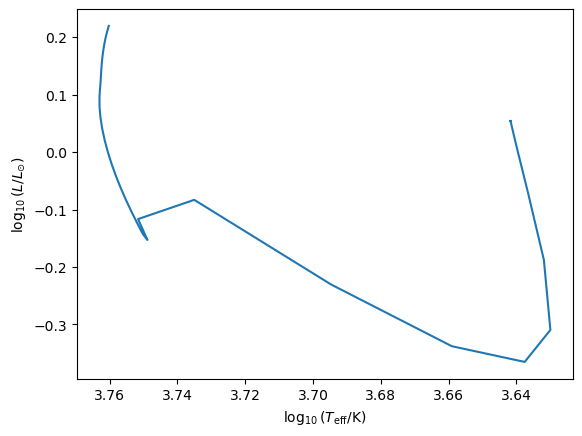

In [23]:
plt.plot(myh.log_Teff,myh.log_L)

# for historical reasons, the HR diagram plots 
# higher temperatures towards the left
plt.gca().invert_xaxis()

# axis labels
plt.xlabel(r'$\log_{10}(T_{\rm eff}/\rm{K})$')
plt.ylabel(r'$\log_{10}(L/L_{\odot})$')

### Luminosity evolution

We can also look at how the surface luminosity of the star (power output that the star radiates) compares to its nuclear burning luminosity (power output from nuclear burning), at different ages.

Text(0, 0.5, '$\\log_{10}(L/L_{\\odot})$')

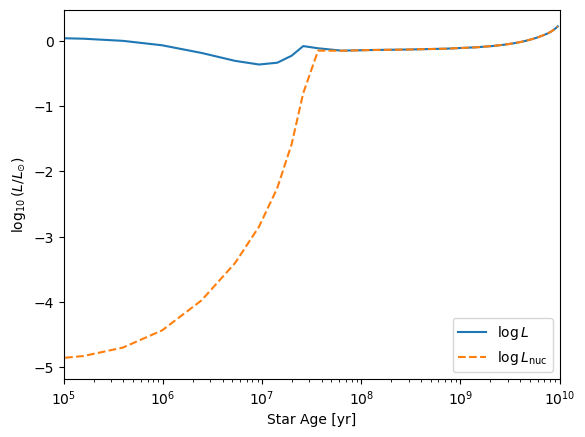

In [24]:
plt.plot(myh.star_age,myh.log_L,label=r'$\log L$')

plt.plot(myh.star_age,myh.log_Lnuc,label=r'$\log L_{\rm nuc}$',ls='--')

# add legend
plt.legend()

# change x axis limits and change to log scale
plt.semilogx()
plt.xlim(1e5,1e10)

# add axis labels
plt.xlabel(r'Star Age [yr]')
plt.ylabel(r'$\log_{10}(L/L_{\odot})$')

You can see that the star starts nuclear burning after $\sim 10^{7}~$yrs, and continues nuclear burning for the next $\sim 10^{10}~$yrs. This is the main sequence lifetime of the Sun. 

During this time, the star remains in thermal equilibrium: it radiates as much energy at its surface as nuclear burning generates at its core. 


### Detour on Kelvin-Helmholtz contraction

Prior to the main sequence, the star is radiating way too much energy than nuclear burning provides. 

This energy has to come from somewhere. The star instead taps into its gravitational potential energy: as it contracts, it releases gravitational potential energy that gets radiated away. 

We call this "Kelvin-Helmholtz contraction".

How long does this phase last? We can do an order-of-magnitude estimate. What that means is that we only care about an accuracy within a factor of 10. 

The timescale is given by 

$
\large
t_{\rm KH} 
\sim \frac{ \rm{available\,energy} }{ \rm{how\,quickly\,energy\,is\,lost} } 
\sim \frac{ G M^{2} / R }{ L } 
$

where $GM^{2}/R$ is the gravitational potential energy of the star, and $L$ is the rate of energy loss by radiation (units of energy per time). 

We can estimate this quickly:

In [56]:
# We'll use cgs units
G = 7e-8 # gravitational constant in cgs units, cm^3/g/s^2
Msun = 2e33 # g
Rsun = 7e10 # cm
Lsun = 4e33 # erg/s

In [61]:
t_kh = G*Msun*Msun/Rsun/Lsun # in sec
t_kh = t_kh / (3e7) # sec to yrs
print('The Kelvin-Helmholtz timescale of the Sun is about {:.0e} yrs'.format(t_kh))

The Kelvin-Helmholtz timescale of the Sun is about 3e+07 yrs


This is way shorter than the lifetime of the Sun (4.6 billion years). That was one of the first clues that made people realize that something other than gravitationanl contraction must be powering the Sun. 

In astronomy, you'll encounter this kind of order-of-magnitude estimate over and over again. 

## Profile

Now let's take a look at the very last profile of your first run. You can download this  here {download}`first_run/profile8.data`

In [26]:
# load profile
myp = mr.MesaData('first_run/profile8.data')

Again, we can take a look at the header information:

In [27]:
myp.header_names

['model_number',
 'num_zones',
 'initial_mass',
 'initial_z',
 'star_age',
 'time_step',
 'Teff',
 'photosphere_L',
 'photosphere_r',
 'center_eta',
 'center_h1',
 'center_he3',
 'center_he4',
 'center_c12',
 'center_n14',
 'center_o16',
 'center_ne20',
 'star_mass',
 'star_mdot',
 'star_mass_h1',
 'star_mass_he3',
 'star_mass_he4',
 'star_mass_c12',
 'star_mass_n14',
 'star_mass_o16',
 'star_mass_ne20',
 'he_core_mass',
 'co_core_mass',
 'fe_core_mass',
 'neutron_rich_core_mass',
 'dynamic_time',
 'kh_timescale',
 'nuc_timescale',
 'power_nuc_burn',
 'power_h_burn',
 'power_he_burn',
 'power_neu',
 'burn_min1',
 'burn_min2',
 'time_seconds',
 'version_number',
 'compiler',
 'build',
 'MESA_SDK_version',
 'math_backend',
 'date',
 'msun',
 'rsun',
 'lsun']

The headers of a profile actually give more information, like the age and model number of this particular profile:

In [43]:
print('Age of profile is: {:.2e}'.format(myp.star_age) )
print('Model number of profile is: {:d}'.format(myp.model_number) )

Age of profile is: 9.57e+09
Model number of profile is: 315


At model number 315, what does the star look like? We can take a look at what profile quantities are available:

In [44]:
myp.bulk_names

('zone',
 'mass',
 'logR',
 'logT',
 'logRho',
 'logP',
 'x_mass_fraction_H',
 'y_mass_fraction_He',
 'z_mass_fraction_metals',
 'pp',
 'cno',
 'tri_alpha')

Here we have the zone number, mass enclosed, radius, etc., of each shell within the star, at model number 315. 

In MESA, zone 1 refers to the very surface, and the zone with the largest number refers to the center. 

Note that Fortran arrays are use 1-based indexing, whereas Python arrays use 0-based indexing. So zone 1 in MESA would be have a python index of 0: myp.zone[0]. 

Text(0.5, 0, 'Zone Number')

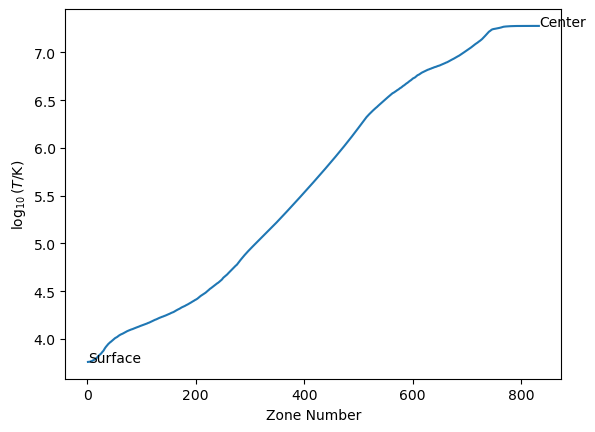

In [50]:
plt.plot(myp.zone,myp.logT)

plt.text(myp.zone[0],myp.logT[0],'Surface') # 0 index in python gives surface
plt.text(myp.zone[-1],myp.logT[-1],'Center') # -1 index in python gives center

plt.ylabel(r'$\log_{10}(T/\rm{K})$')
plt.xlabel(r'Zone Number')

From the plot we can see that the center has a temperature about $10^{7}~$K. This is roughly the temperature needed for hydrogen burning. 

We can also print this out:

In [55]:
print('T = {:.2e} K'.format(10**myp.logT[-1]))

T = 1.89e+07 K


We'll plot one last thing: the pressure profile of the star as a function of the mass enclosed. 

The mass enclosed is just what you'd guess: imagine slicing the star into shells of different radii. The mass that is within each spherical shell yields the mass enclosed. At the center, the mass enclosed is zero. 

Text(0, 0.5, '$\\log_{10} (P / \\rm{dyn}\\,\\rm{cm}^{2})$')

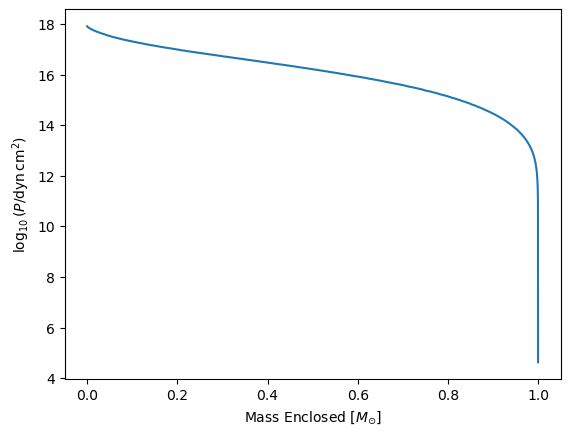

In [65]:
plt.plot(myp.mass,myp.logP)

plt.xlabel(r'Mass Enclosed [$M_{\odot}$]')
plt.ylabel(r'$\log_{10} (P / \rm{dyn}\,\rm{cm}^{2})$')

The pressure is highest at the center, and decreases towards the surface. 

This difference in pressure, or the *pressure gradient*, creates an outward force that opposes the inward pull of gravity. When a star is in such balance, we say that it is in *hydrostatic equilibrium/balance*. 